Dec0922: This is a continuous, 33-minute file featuring identical stims. at minutes 5, 12, 19, and 27 (the last stim. was administered a minute later than planned due to an issue at the imaging rig); the corresponding time steps would be 122175, 293220, 464265, and 659745. The protocol used in this experiment is very similar to the one employed in the Nov2122 file, which, I believe, is the one from which you've been generating your existing analysis, Vince. Despite this similarity, the response of the recorded population to repeated stimulation is different here than in the Nov2122 file, which might make it worthwhile for you to analyze. 

In [1]:
'''
import h5py

file_path = 'Dec0922_1_peaks.mat'

with h5py.File(file_path, 'r') as f:
    # List all variables in the MAT file
    print(list(f.keys()))

    # Example: access a variable called 'peaks'
    peaks = f['peaks'][:]
    print(peaks.shape)
'''

"\nimport h5py\n\nfile_path = 'Dec0922_1_peaks.mat'\n\nwith h5py.File(file_path, 'r') as f:\n    # List all variables in the MAT file\n    print(list(f.keys()))\n\n    # Example: access a variable called 'peaks'\n    peaks = f['peaks'][:]\n    print(peaks.shape)\n"

In [2]:
'''
## Save peaks as npy file
import numpy as np
np.save('Dec0922_peaks.npy', peaks)
'''

"\n## Save peaks as npy file\nimport numpy as np\nnp.save('Dec0922_peaks.npy', peaks)\n"

In [3]:
## Import peaks from npy file
import numpy as np
peaks = np.load('../data/sea_slug/Dec0922_peaks.npy')

In [4]:
peaks.shape

(806144, 88)

In [5]:
import sys
sys.getsizeof(peaks)

128

In [6]:
import numpy as np
def count_zeros_ones(series, n_bins):
    """
    Count the number of 0s and 1s in each bin of a 0/1 series.

    Parameters
    ----------
    series : array-like
        1D array or list of 0s and 1s.
    n_bins : int
        Number of bins to split the series into.

    Returns
    -------
    counts_0 : np.ndarray
        Array of counts of 0s per bin.
    counts_1 : np.ndarray
        Array of counts of 1s per bin.
    """
    ## Initial parameters
    series = np.asarray(series)
    bin_edges = np.linspace(0, len(series), n_bins + 1, dtype=int)
    counts_0 = np.zeros(n_bins, dtype=int)
    counts_1 = np.zeros(n_bins, dtype=int)
    ## Obtain the bins and counts per bin
    for i in range(n_bins):
        start = bin_edges[i]
        end = bin_edges[i + 1]
        bin_data = series[start:end]
        counts_0[i] = np.sum(bin_data == 0)
        counts_1[i] = np.sum(bin_data == 1)
    ## Return counts
    return counts_0, counts_1

In [7]:
n_bins = 33
n_nodes = peaks.shape[1]
counts_peaks = np.zeros((n_nodes, n_bins), dtype=int)
for i in range(n_nodes):
    counts_peaks[i] = count_zeros_ones(peaks[:,i], n_bins)[1]

In [8]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

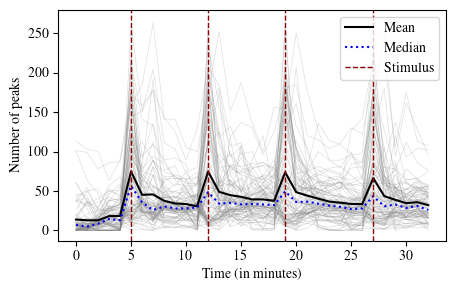

In [9]:
plt.figure(figsize=(5, 3))
plt.plot(counts_peaks.T, color='gray', alpha=0.25, lw=0.5)
plt.plot(counts_peaks.mean(axis=0), color='black', lw=1.5, label='Mean')
plt.plot(np.median(counts_peaks,axis=0), color='blue', lw=1.5, label='Median', ls='dotted')
for j, p in enumerate([5,12,19,27]):
    if j == 0:
        plt.axvline(x=p, ls='dashed', c='DarkRed', label='Stimulus', lw=1.0)
    else:
        plt.axvline(x=p, ls='dashed', c='DarkRed', lw=1.0)
plt.legend()
plt.xlabel('Time (in minutes)')
plt.ylabel('Number of peaks')
plt.savefig('../figures/peaks_Dec0922.pdf', bbox_inches='tight')
plt.show()

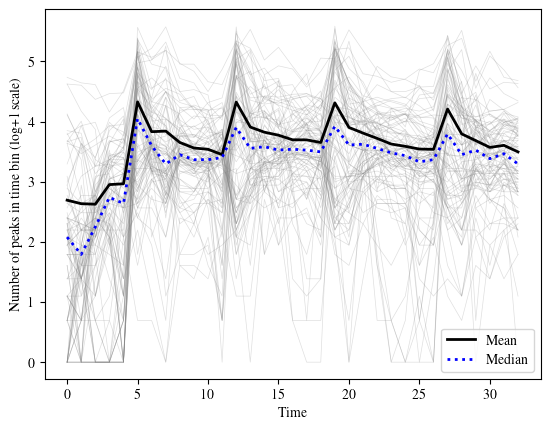

In [10]:
plt.plot(np.log(counts_peaks.T+1), color='gray', alpha=0.25, lw=0.5)
plt.plot(np.log(counts_peaks.mean(axis=0)+1), color='black', lw=2, label='Mean')
plt.plot(np.median(np.log(counts_peaks+1), axis=0), color='blue', lw=2, label='Median', ls='dotted')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Number of peaks in time bin (log+1 scale)')
plt.savefig('../figures/peaks_log_scale_Dec0922.pdf', bbox_inches='tight')
plt.show()